In [2]:
import json

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [4]:
import json
file = "data/episodes_with_showdowns_clean_v2.json"
with open(file, 'r') as f:
    data = json.load(f)

In [5]:
len(data)

6175

In [6]:
# make emperical data a pandas dataframe with set 
empirical_data = [] # ['P1Spin1', 'P1Spin2', 'P2Spin1', 'P2Spin2', 'P3Spin1', 'P3Spin2', 'P1Wins', 'P2Wins', 'P3Wins']

for show in data:
    for showdown_instance in show['showcase_showdowns_structured']:
        if(len(showdown_instance['contestants']) != 3):
            continue
        try:
            P1S1 = showdown_instance['contestants'][0]['spins'][0]
            if (len(showdown_instance['contestants'][0]['spins']) > 1):
                P1S2 = showdown_instance['contestants'][0]['spins'][1]
            else:
                P1S2 = 0
            P2S1 = showdown_instance['contestants'][1]['spins'][0]
            if (len(showdown_instance['contestants'][1]['spins']) > 1):
                P2S2 = showdown_instance['contestants'][1]['spins'][1]
            else:
                P2S2 = 0
            P3S1 = showdown_instance['contestants'][2]['spins'][0]
            if (len(showdown_instance['contestants'][2]['spins']) > 1):
                P3S2 = showdown_instance['contestants'][2]['spins'][1]
            else:
                P3S2 = 0
            P1Wins = P2Wins = P3Wins = 0
            if (showdown_instance['winner_computed'] == 0):
                P1Wins = 1
            elif (showdown_instance['winner_computed'] == 1):
                P2Wins = 1
            elif (showdown_instance['winner_computed'] == 2):
                P3Wins = 1
            else:
                continue 
            empirical_data.append([P1S1, P1S2, P2S1, P2S2, P3S1, P3S2, P1Wins, P2Wins, P3Wins])
        except Exception as e:
            continue

In [7]:
len(empirical_data)

11215

In [8]:
data[0]['showcase_showdowns_structured'][0]['contestants'][0]['spins']

[95]

In [9]:
empirical_df = pd.DataFrame(empirical_data, columns=['P1Spin1', 'P1Spin2', 'P2Spin1', 'P2Spin2', 'P3Spin1', 'P3Spin2', 'P1Wins', 'P2Wins', 'P3Wins'])
# sum up all the wins for each combination of P1Spin1, P1Spin2, P2Spin1, P2Spin2, P3Spin1, P3Spin2
empirical_df = empirical_df.groupby(['P1Spin1', 'P1Spin2', 'P2Spin1', 'P2Spin2', 'P3Spin1', 'P3Spin2']).sum().reset_index()
empirical_df

,P1Spin1,P1Spin2,P2Spin1,P2Spin2,P3Spin1,P3Spin2,P1Wins,P2Wins,P3Wins
0,5,5,5,35,30,20,0,0,1
1,5,5,10,75,5,30,0,1,0
2,5,5,15,60,35,30,0,1,0
3,5,5,15,80,85,100,0,1,0
4,5,5,15,80,100,0,0,0,1
...,...,...,...,...,...,...,...,...,...
10925,100,0,100,0,65,0,1,0,0
10926,100,0,100,0,70,35,0,1,0
10927,100,0,100,0,80,40,0,1,0
10928,100,0,100,0,90,45,1,0,0


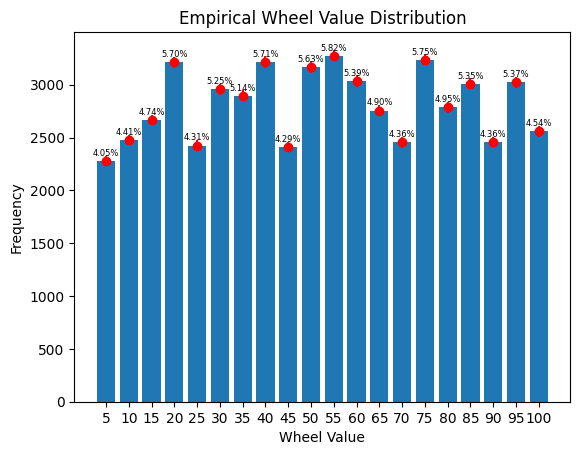

In [ ]:
wheel_values = []
for i in range(21):
    wheel_values.append(0)
for x in empirical_data:
    for spin in x[0:6]:
        wheel_values[spin//5] += 1

# plot wheel values execpt 0
plt.bar(range(1, 21), wheel_values[1:21])
plt.xlabel('Wheel Value')
# whele value labels should be an interger multiple of 5
plt.xticks(ticks=range(1, 21), labels=[i*5 for i in range(1, 21)])
plt.ylabel('Frequency')
plt.title('Empirical Wheel Value Distribution')
# label percentage on top of each bar
total_spins = sum(wheel_values[1:21])
for i, v in enumerate(wheel_values[1:21]):
    # size the text much smaller
    plt.text(i + 1, v + 50, f"{v / total_spins:.2%}", ha='center', fontsize=6)
# include error bars showing standard deviation
# std_dev = [np.sqrt((v / total_spins) * (1 - (v / total_spins)) * total_spins) for v in wheel_values[1:21]]
# plt.errorbar(range(1, 21), wheel_values[1:21], yerr=std_dev, fmt='o', color='red')
# save plot
plt.savefig('plots/empirical_wheel_value_distribution.png')
plt.show()


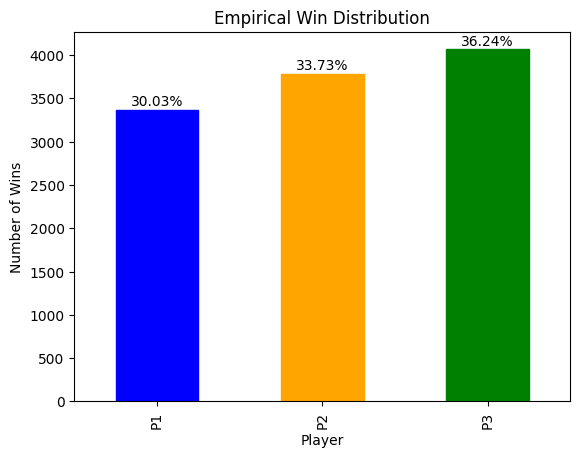

In [ ]:
# Bar graph for the number of wins of P1, P2, and P3
empirical_df[['P1Wins', 'P2Wins', 'P3Wins']].sum().plot(kind='bar')
plt.title('Empirical Win Distribution')
plt.xlabel('Player')
plt.ylabel('Number of Wins')
plt.xticks(ticks=[0, 1, 2], labels=['P1', 'P2', 'P3'])
# label to top of the bar with the win percentage
total = empirical_df[['P1Wins', 'P2Wins', 'P3Wins']].sum().sum()
for i, v in enumerate(empirical_df[['P1Wins', 'P2Wins', 'P3Wins']].sum()):
    plt.text(i, v + 50, f"{v / total:.2%}", ha='center')

plt.savefig('plots/empirical_win_distribution.png')
plt.show()

# save plot


In [26]:
wins = [0, 0, 0]
for i in range(len(data)):
    for j in range(len(data[i]['showcase_showdowns_structured'])):
        if data[i]['showcase_showdowns_structured'][j]['winner_computed'] is not None and data[i]['showcase_showdowns_structured'][j]['winner_computed'] >= 0 and data[i]['showcase_showdowns_structured'][j]['winner_computed'] <= 2:
            wins[data[i]['showcase_showdowns_structured'][j]['winner_computed']] += 1

In [27]:
wins /= np.sum(wins)
print(wins)

[0.31312435 0.3350844  0.35179125]


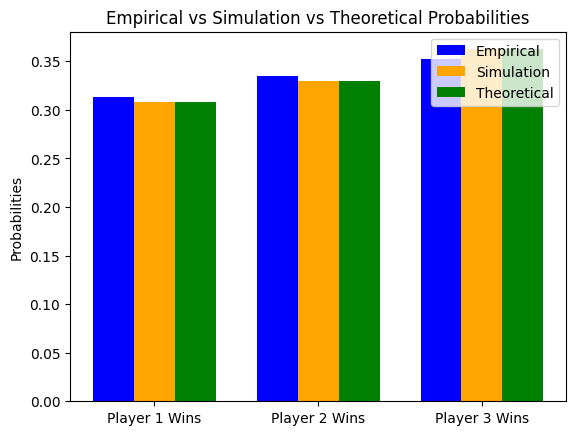

In [28]:
# Bar chart for 3 sets of three probabilities
empirical_data = wins
simulation_data = [963/3125, 3297231/10000000, 3621169/10000000]
theoretical_data = [6311/20480, 42188819/128000000, 46367431/128000000]
labels = ['Player 1 Wins', 'Player 2 Wins', 'Player 3 Wins']
x = np.arange(len(labels))  # the label locations
width = 0.25  # the width of the bars
fig, ax = plt.subplots()
bars1 = ax.bar(x - width, empirical_data, width, label='Empirical', color='blue')
bars2 = ax.bar(x, simulation_data, width, label='Simulation', color='orange')
bars3 = ax.bar(x + width, theoretical_data, width, label='Theoretical', color='green')
# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Probabilities')
ax.set_title('Empirical vs Simulation vs Theoretical Probabilities')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.savefig('plots/empirical_simulation_theoretical_comparison.png')
plt.show()

In [29]:
theoretical_data

[0.308154296875, 0.3296001484375, 0.3622455546875]

In [24]:
simulation_data = [963/3125, 3297231/10000000, 3621169/10000000]
theoretical_data = [6311/20480, 42188819/128000000, 46367431/128000000]
# get the fractions values rounded to 2 decimal places
simulation_data_rounded = [round(x, 4) for x in simulation_data]
theoretical_data_rounded = [round(x, 4) for x in theoretical_data]
simulation_data_rounded, theoretical_data_rounded

([0.3082, 0.3297, 0.3621], [0.3082, 0.3296, 0.3622])

In [36]:
p1 = pd.read_csv('data/optimal_policy/player1DP.csv')
p1 = p1[['Player1Spin', "WinProb1NoSpin", "WinProb1Spin", "PolicyDecision"]]
p1["Δpp"] = p1["WinProb1Spin"] - p1["WinProb1NoSpin"]
p1["PolicyDecision"] = p1["PolicyDecision"].map({0: "No Spin", 1: "Spin"})
p1["Player1Spin"] = 5 * p1["Player1Spin"]
p1

,Player1Spin,WinProb1NoSpin,WinProb1Spin,PolicyDecision,Δpp
0,5,0.000344,0.205947,Spin,0.205603
1,10,0.001215,0.205886,Spin,0.204671
2,15,0.002852,0.205743,Spin,0.202891
3,20,0.005397,0.205473,Spin,0.200076
4,25,0.009065,0.205020,Spin,0.195955
5,30,0.014146,0.204313,Spin,0.190167
6,35,0.021006,0.203263,Spin,0.182257
7,40,0.030086,0.201758,Spin,0.171672
8,45,0.041902,0.199663,Spin,0.157761
9,50,0.057044,0.196811,Spin,0.139767


In [30]:
# read rationality

all_quantal = pd.read_csv('data/quantal_response/all_quantal/quantal_response_results.csv')
C1_quantal = pd.read_csv('data/quantal_response/C1_quantal/quantal_response_results.csv')
C2_quantal = pd.read_csv('data/quantal_response/C2_quantal/quantal_response_results.csv')
C3_quantal = pd.read_csv('data/quantal_response/C3_quantal/quantal_response_results.csv')

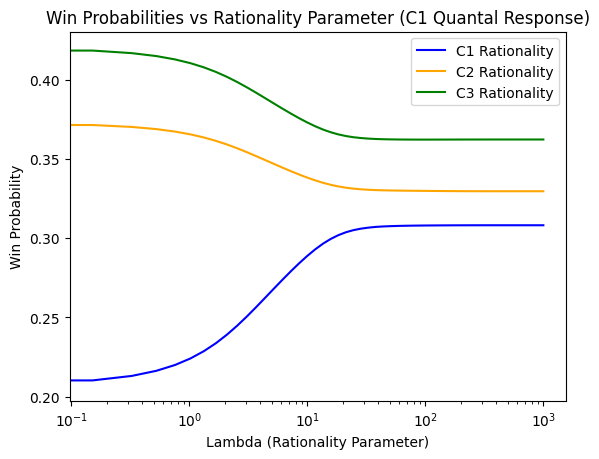

In [32]:
# Graph rationality values for C1 quantal (for each lambda plot win probability for C1, C2, and C3 with different lines)
plt.plot(C1_quantal['Lambda'], C1_quantal['FirstPlayerWinProb'], label='C1 Rationality', color='blue')
plt.plot(C1_quantal['Lambda'], C1_quantal['SecondPlayerWinProb'], label='C2 Rationality', color='orange')
plt.plot(C1_quantal['Lambda'], C1_quantal['ThirdPlayerWinProb'], label='C3 Rationality', color='green')
plt.xlabel('Lambda (Rationality Parameter)')
# put x on a log scale
plt.xscale('log')
plt.ylabel('Win Probability')
plt.title('Win Probabilities vs Rationality Parameter (C1 Quantal Response)')
plt.legend()
plt.savefig('plots/rationality_C1_quantal_response.png')
plt.show()

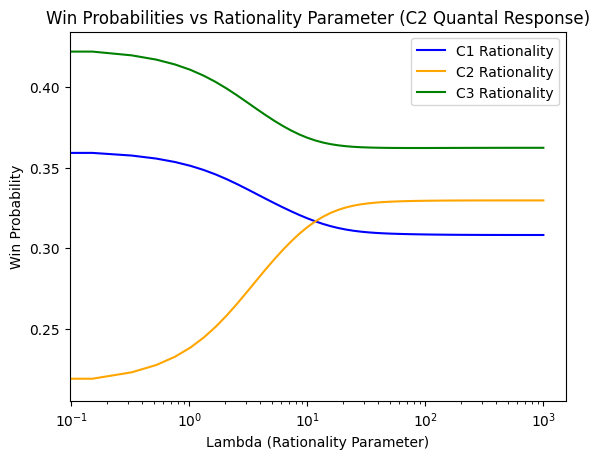

In [33]:
# Graph rationality values for C2 quantal (for each lambda plot win probability for C1, C2, and C3 with different lines)
plt.plot(C2_quantal['Lambda'], C2_quantal['FirstPlayerWinProb'], label='C1 Rationality', color='blue')
plt.plot(C2_quantal['Lambda'], C2_quantal['SecondPlayerWinProb'], label='C2 Rationality', color='orange')
plt.plot(C2_quantal['Lambda'], C2_quantal['ThirdPlayerWinProb'], label='C3 Rationality', color='green')
plt.xlabel('Lambda (Rationality Parameter)')
# put x on a log scale
plt.xscale('log')
plt.ylabel('Win Probability')
plt.title('Win Probabilities vs Rationality Parameter (C2 Quantal Response)')
plt.legend()
plt.savefig('plots/rationality_C2_quantal_response.png')
plt.show()

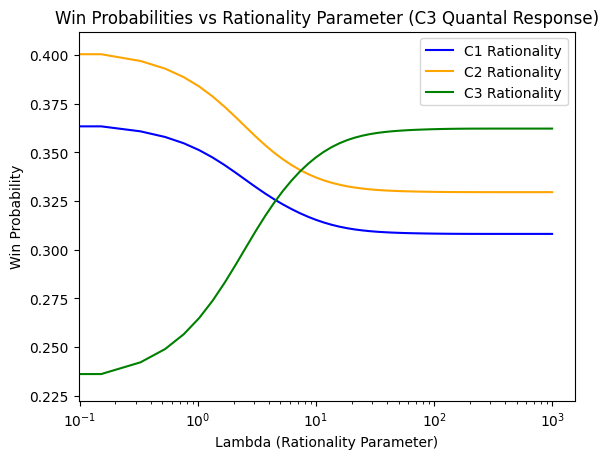

In [34]:
# Graph rationality values for C3 quantal (for each lambda plot win probability for C1, C2, and C3 with different lines)
plt.plot(C3_quantal['Lambda'], C3_quantal['FirstPlayerWinProb'], label='C1 Rationality', color='blue')
plt.plot(C3_quantal['Lambda'], C3_quantal['SecondPlayerWinProb'], label='C2 Rationality', color='orange')
plt.plot(C3_quantal['Lambda'], C3_quantal['ThirdPlayerWinProb'], label='C3 Rationality', color='green')
plt.xlabel('Lambda (Rationality Parameter)')
# put x on a log scale
plt.xscale('log')
plt.ylabel('Win Probability')
plt.title('Win Probabilities vs Rationality Parameter (C3 Quantal Response)')
plt.legend()
plt.savefig('plots/rationality_C3_quantal_response.png')
plt.show()

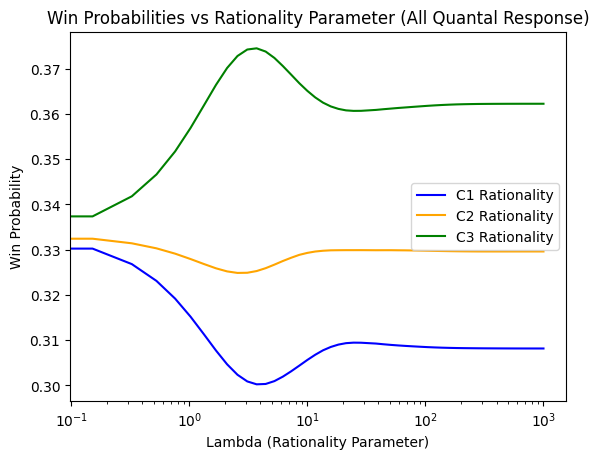

In [35]:
# Graph rationality values for all quantal (for each lambda plot win probability for C1, C2, and C3 with different lines)
plt.plot(all_quantal['Lambda'], all_quantal['FirstPlayerWinProb'], label='C1 Rationality', color='blue')
plt.plot(all_quantal['Lambda'], all_quantal['SecondPlayerWinProb'], label='C2 Rationality', color='orange')
plt.plot(all_quantal['Lambda'], all_quantal['ThirdPlayerWinProb'], label='C3 Rationality', color='green')
plt.xlabel('Lambda (Rationality Parameter)')
# put x on a log scale
plt.xscale('log')
plt.ylabel('Win Probability')
plt.title('Win Probabilities vs Rationality Parameter (All Quantal Response)')
plt.legend()
plt.savefig('plots/rationality_all_quantal_response.png')
plt.show()